## Analysis of Causal Results

In [1]:
def default_params(): 
    return {
        'input_path' : '/workspaces/CodeSmells/data/extension/causality/results',
        'output_plots' : '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots',
        'treatment' : 'T4',
    }
params = default_params()

### Imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

### Dataset loading

In [4]:
# #code_smell_actual_prob_median, #code_smell_max_prob_median, #code_smell_min_prob_median, 
# #code_smell_actual_prob_mean, #code_smell_max_prob_mean, #code_smell_min_prob_mean, 
# #code_smell_psc_entropy, #code_smell_psc_relative,

####### results per smell, binary treatment 
causal_results_per_smell_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_psc_relative.json"),
    'code_smell_actual_prob_median' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_actual_prob_median.json"),
    'code_smell_actual_prob_mean' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_actual_prob_mean.json"),
    'code_smell_psc_entropy' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_psc_entropy.json"),
    'code_smell_actual_prob_median_trans' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_actual_prob_median_trans.json"),
}
####### results all smells, binary treatment 
causal_results_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_psc_relative_ALL.json"),
    #'code_smell_actual_prob_median': pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_actual_prob_median_ALL.json"),
    #'code_smell_actual_prob_mean' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_actual_prob_mean_ALL.json"),
    #'code_smell_psc_entropy' : pd.read_json(f"{params['input_path']}/{params['treatment']}/code_smell_psc_entropy_ALL.json"),
}
####### results per smell, categorical treatment 
causal_results_per_smell_categorical_dict = {
    #'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_psc_relative.json"),
    #'code_smell_actual_prob_median' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_actual_prob_median.json"),
    #'code_smell_actual_prob_mean' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_actual_prob_mean.json"),
    #'code_smell_psc_entropy' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_psc_entropy.json"),
}
####### results all smell, categorical treatment 
causal_results_categorical_dict = {
    #'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_psc_relative_ALL.json"),
    #'code_smell_actual_prob_median': pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_actual_prob_median_ALL.json"),
    #'code_smell_actual_prob_mean' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_actual_prob_mean_ALL.json"),
    #'code_smell_psc_entropy' : pd.read_json(f"{params['input_path']}/{params['treatment']}/categorical/code_smell_psc_entropy_ALL.json"),
}

In [5]:
causal_results_per_smell_dict['code_smell_actual_prob_median'].sort_values(by=['estimated_effect'], ascending=False)

,method_name,pearson_corr,spearman_corr,kendall_corr,estimated_effect,refutation_placebo_permute,refutation_unobserved_confounder,refutation_subset,intervention,s_msg_id
327,backdoor.propensity_score_matching,0.222315,0.210651,0.172389,0.193749,"{'result': {'p_value': 0.84, 'is_statistically...","{'result': None, 'new_effect': [0.1718798597, ...","{'result': {'p_value': 0.16, 'is_statistically...",P4,W0102
144,backdoor.propensity_score_matching,-0.015942,-0.025718,-0.021010,0.150454,"{'result': {'p_value': 0.9, 'is_statistically_...","{'result': None, 'new_effect': [0.129376897300...","{'result': {'p_value': 0.4, 'is_statistically_...",P3,C0321
150,backdoor.propensity_score_matching,-0.009118,-0.013455,-0.010991,0.129769,"{'result': {'p_value': 0.9400000000000001, 'is...","{'result': None, 'new_effect': [0.0958380628, ...","{'result': {'p_value': 0.48, 'is_statistically...",P2,C0321
108,backdoor.propensity_score_matching,-0.036591,-0.051026,-0.041689,0.119805,"{'result': {'p_value': 0.92, 'is_statistically...","{'result': None, 'new_effect': [-0.0363788014,...","{'result': {'p_value': 0.24, 'is_statistically...",P3,C0103
147,backdoor.propensity_score_matching,-0.018112,-0.027983,-0.022860,0.104195,"{'result': {'p_value': 0.98, 'is_statistically...","{'result': None, 'new_effect': [0.057427931, 0...","{'result': {'p_value': 0.52, 'is_statistically...",P4,C0321
...,...,...,...,...,...,...,...,...,...,...
273,backdoor.propensity_score_matching,-0.026015,-0.029660,-0.024231,-0.148618,"{'result': {'p_value': 0.9, 'is_statistically_...","{'result': None, 'new_effect': [-0.1794681386,...","{'result': {'p_value': 0.32, 'is_statistically...",P4,W0719
360,backdoor.propensity_score_matching,-0.119739,-0.112120,-0.091640,-0.163166,"{'result': {'p_value': 0.92, 'is_statistically...","{'result': None, 'new_effect': [-0.2130073627,...","{'result': {'p_value': 0.54, 'is_statistically...",P3,W0601
87,backdoor.propensity_score_matching,-0.069362,-0.072899,-0.059551,-0.499432,"{'result': {'p_value': 1.0, 'is_statistically_...","{'result': None, 'new_effect': [-0.5292220644,...","{'result': {'p_value': 0.1, 'is_statistically_...",P2,C0304
81,backdoor.propensity_score_matching,-0.107650,-0.135204,-0.110449,-0.521161,"{'result': {'p_value': 0.88, 'is_statistically...","{'result': None, 'new_effect': [-0.55677416740...","{'result': {'p_value': 0.02, 'is_statistically...",P3,C0304


In [6]:
causal_results_per_smell_dict['code_smell_actual_prob_median'].groupby(['intervention', 's_msg_id']).describe()

pearson_corr                                    \
                             count      mean           std       min   
intervention s_msg_id                                                  
P2           C0103             3.0 -0.018224  0.000000e+00 -0.018224   
             C0114             3.0 -0.058683  0.000000e+00 -0.058683   
             C0116             3.0 -0.053423  8.498375e-18 -0.053423   
             C0123             3.0 -0.020036  0.000000e+00 -0.020036   
             C0200             3.0 -0.010025  0.000000e+00 -0.010025   
...                            ...       ...           ...       ...   
P4           W0718             3.0 -0.025861  4.249187e-18 -0.025861   
             W0719             3.0 -0.026015  0.000000e+00 -0.026015   
             W1309             3.0 -0.017871  0.000000e+00 -0.017871   
             W1406             3.0 -0.018626  0.000000e+00 -0.018626   
             W1514             3.0 -0.016327  0.000000e+00 -0.016327   

                                                              spearman_corr  \
                            25%       50%       75%       max         count   
intervention s_msg_id                                                         
P2           C0103    -0.018224 -0.018224 -0.018224 -0.018224           3.0   
             C0114    -0.058683 -0.058683 -0.058683 -0.058683           3.0   
             C0116    -0.053423 -0.053423 -0.053423 -0.053423           3.0   
             C0123    -0.020036 -0.020036 -0.020036 -0.020036           3.0   
             C0200    -0.010025 -0.010025 -0.010025 -0.010025           3.0   
...                         ...       ...       ...       ...           ...   
P4           W0718    -0.025861 -0.025861 -0.025861 -0.025861           3.0   
             W0719    -0.026015 -0.026015 -0.026015 -0.026015           3.0   
             W1309    -0.017871 -0.017871 -0.017871 -0.017871           3.0   
             W1406    -0.018626 -0.018626 -0.018626 -0.018626           3.0   
             W1514    -0.016327 -0.016327 -0.016327 -0.016327           3.0   

                                 ... kendall_corr           estimated_effect  \
                           mean  ...          75%       max            count   
intervention s_msg_id            ...                                           
P2           C0103     0.019496  ...     0.015929  0.015929              3.0   
             C0114    -0.049384  ...    -0.040343 -0.040343              3.0   
             C0116     0.041271  ...     0.033726  0.033726              3.0   
             C0123    -0.025073  ...    -0.020484 -0.020484              3.0   
             C0200    -0.089706  ...    -0.073286 -0.073286              3.0   
...                         ...  ...          ...       ...              ...   
P4           W0718    -0.034094  ...    -0.027852 -0.027852              3.0   
             W0719    -0.029660  ...    -0.024231 -0.024231              3.0   
             W1309    -0.022330  ...    -0.018243 -0.018243              3.0   
             W1406    -0.019905  ...    -0.016262 -0.016262              3.0   
             W1514    -0.033886  ...    -0.027682 -0.027682              3.0   

                                                                         \
                           mean       std       min       25%       50%   
intervention s_msg_id                                                     
P2           C0103    -0.001955  0.019132 -0.013001 -0.013001 -0.013001   
             C0114    -0.033988  0.012526 -0.048452 -0.037604 -0.026757   
             C0116    -0.008053  0.000423 -0.008297 -0.008297 -0.008297   
             C0123    -0.010375  0.003190 -0.012217 -0.012217 -0.012217   
             C0200    -0.002293  0.001410 -0.003921 -0.002700 -0.001479   
...                         ...       ...       ...       ...       ...   
P4           W0718    -0.014839  0.002588 -0.016333 -0.016333 -0.016333   
             W0719    -0.058485  0.

### Plots

In [7]:
def plot_correlations(causal_df, outcome, correlation, method_name, output_dir, intervention = None):
    # Transforming the DataFrame using melt
    causal_df = causal_df[
        (causal_df['method_name'] == method_name)].copy()
    if intervention:
        causal_df = causal_df[
            (causal_df['method_name'] == method_name) &(causal_df['intervention'] == intervention)
        ].copy()
    correlation_plot_df = causal_df.melt(id_vars=['s_msg_id'], value_vars=[correlation, 'estimated_effect'],  var_name='type', value_name='value')

    # Create the plot
    plt.figure(figsize=(40, 6))
    barplot = sns.barplot(
        palette='mako',
        data=correlation_plot_df,
        x="s_msg_id",
        y="value",
        hue="type",
        alpha=0.8,
        errorbar=None)

    # Improve x-axis readability
    plt.xlabel("Smell Id", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.title(f"{correlation} vs ATE. Outcome [{outcome}], Treatment [{intervention}]", fontsize=14)

    # Move the legend outside for clarity
    plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    output_dir = f"{output_dir}/{params['treatment']}/{method_name}"
    if intervention:
        output_dir = f"{output_dir}/{params['treatment']}/{intervention}/{method_name}"

    create_folder(output_dir)
    plt.savefig(f"{output_dir}/{outcome}_{correlation}.png", bbox_inches="tight", dpi=300)
    plt.close()



In [8]:
def plot_correlations_binary_treatment(causal_results_per_smell_dict, method_names):
    for outcome, causal_df in causal_results_per_smell_dict.items():
        for correlation in ['pearson_corr', 'spearman_corr', 'kendall_corr']:
            for method_name in method_names:
                for intervention in causal_df['intervention'].unique():
                    plot_correlations(causal_df, outcome, correlation, method_name, '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots/binary_treatment', intervention)

In [9]:
def plot_correlations_categorical_treatment(causal_results_per_smell_dict, method_names):
    for outcome, causal_df in causal_results_per_smell_dict.items():
        for correlation in ['pearson_corr', 'spearman_corr', 'kendall_corr']:
            for method_name in method_names:
                    plot_correlations(causal_df, outcome, correlation, method_name, '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots/categorical_treatment')

In [10]:
method_names = ['backdoor.generalized_linear_model', 'backdoor.propensity_score_matching', 'backdoor.propensity_score_stratification', 'backdoor.propensity_score_weighting']

In [11]:
#if params['treatment'] in ['T1', 'T2', 'T3', 'T4']:
#    plot_correlations_binary_treatment(causal_results_per_smell_dict, method_names)

In [12]:
#if params['treatment'] in ['T2']:
#    plot_correlations_categorical_treatment(causal_results_per_smell_categorical_dict, method_names)

### Summary

In [13]:
outcome = 'code_smell_actual_prob_median'
#causal_results_per_smell_categorical_dict[outcome].head(2)

             estimated_effect                                              \
                        count      mean       std     min     25%     50%   
intervention                                                                
P2                       41.0 -0.022246  0.085675 -0.4994 -0.0330 -0.0067   
P3                       41.0 -0.032644  0.098760 -0.5212 -0.0380 -0.0074   
P4                       41.0 -0.034734  0.100300 -0.5242 -0.0565 -0.0102   

                             refutation_placebo_permute            ...  \
                 75%     max                      count      mean  ...   
intervention                                                       ...   
P2           -0.0001  0.1298                       41.0  0.008234  ...   
P3           -0.0015  0.1505                       41.0  0.000929  ...   
P4           -0.0020  0.1937                       41.0 -0.002820  ...   

                             pearson_corr                                \
                 

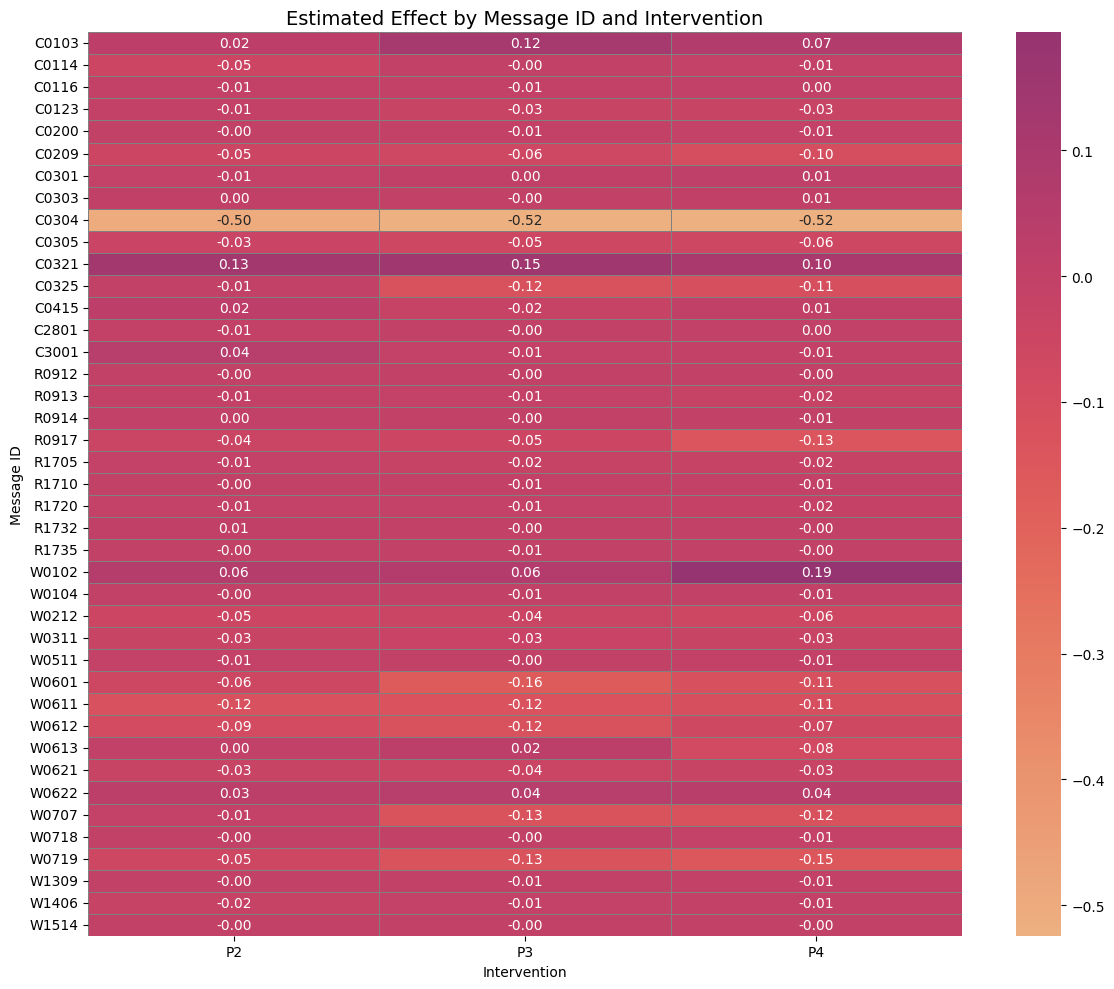

In [17]:
### BINARY TREATMENT

# #code_smell_actual_prob_median, #code_smell_max_prob_median, #code_smell_min_prob_median, 
# #code_smell_actual_prob_mean, #code_smell_max_prob_mean, #code_smell_min_prob_mean, 
# #code_smell_psc_entropy, #code_smell_psc_relative,

outcome = 'code_smell_actual_prob_median'
summary_df = causal_results_per_smell_dict[outcome][causal_results_per_smell_dict[outcome]['method_name']=='backdoor.propensity_score_matching'].copy()
#summary_df = summary_df[['intervention','s_msg_id','pearson_corr','estimated_effect', 'refutation_placebo_permute']].sort_values(by='estimated_effect', ascending=False)
summary_df = summary_df[['intervention','s_msg_id','estimated_effect', 'refutation_placebo_permute', 'pearson_corr']].sort_values(by='estimated_effect', ascending=False)
#summary_df['pearson_corr'] = summary_df['pearson_corr'].round(4)
summary_df['estimated_effect'] = summary_df['estimated_effect'].round(4)
summary_df['refutation_placebo_permute'] = summary_df['refutation_placebo_permute'].map(lambda result: result['new_effect'])
summary_df['refutation_placebo_permute'] = summary_df['refutation_placebo_permute'].round(4)

print(summary_df.groupby(['intervention']).describe())

# Assume df is the original dataframe
pivot_df = summary_df.pivot(index='s_msg_id', columns='intervention', values='estimated_effect')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="flare", center=0, linewidths=0.5, linecolor='gray')
plt.title("Estimated Effect by Message ID and Intervention", fontsize=14)
plt.xlabel("Intervention")
plt.ylabel("Message ID")
plt.tight_layout()
plt.show()




In [29]:
summary_df[summary_df['s_msg_id']=='W0719']

,intervention,s_msg_id,estimated_effect,refutation_placebo_permute,pearson_corr
276,P2,W0719,-0.0531,0.0063,-0.023149
270,P3,W0719,-0.1281,0.0356,-0.016723
273,P4,W0719,-0.1486,-0.0093,-0.026015


### CATEGORICAL TREATMENT (T3 ONLY MODEL SIZE)

outcome = 'code_smell_actual_prob_median'
summary_df = causal_results_per_smell_categorical_dict[outcome][causal_results_per_smell_categorical_dict[outcome]['method_name']=='backdoor.generalized_linear_model'].copy()
#summary_df = summary_df[['intervention','s_msg_id','pearson_corr','estimated_effect', 'refutation_placebo_permute']].sort_values(by='estimated_effect', ascending=False)
summary_df = summary_df[['s_msg_id','estimated_effect', 'refutation_placebo_permute']].sort_values(by='estimated_effect', ascending=False)
#summary_df['pearson_corr'] = summary_df['pearson_corr'].round(4)
summary_df['estimated_effect'] = summary_df['estimated_effect'].round(4)
summary_df['refutation_placebo_permute'] = summary_df['refutation_placebo_permute'].map(lambda result: result['new_effect'])
summary_df['refutation_placebo_permute'] = summary_df['refutation_placebo_permute'].round(4)


df_sorted = summary_df.sort_values('estimated_effect')
plt.figure(figsize=(10, 8))
plt.barh(df_sorted['s_msg_id'], df_sorted['estimated_effect'], color='steelblue')
plt.xlabel('Estimated Effect')
plt.title('Estimated Effects by Message ID')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

